In [1]:
import pandas as pd

In [2]:
pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
data=pd.read_excel("Delinquency_prediction_dataset.xlsx")

In [4]:
data.shape
data

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,CUST0496,71,48307.0,688.0,0.486522,2,0,12707.0,0.373033,retired,9,Business,Phoenix,On-time,On-time,Missed,On-time,On-time,Late
496,CUST0497,60,86180.0,836.0,0.608174,2,1,45595.0,0.291943,Unemployed,18,Student,Houston,On-time,On-time,Late,Late,Late,Missed
497,CUST0498,54,152326.0,847.0,0.676950,0,0,44449.0,0.104839,Employed,16,Student,Phoenix,On-time,Late,Late,On-time,Late,Missed
498,CUST0499,50,105852.0,343.0,0.700643,2,1,11155.0,0.236477,Employed,11,Student,Phoenix,Late,On-time,Late,Missed,On-time,Missed


In [5]:
data.isnull().sum()

Customer_ID              0
Age                      0
Income                  39
Credit_Score             2
Credit_Utilization       0
Missed_Payments          0
Delinquent_Account       0
Loan_Balance            29
Debt_to_Income_Ratio     0
Employment_Status        0
Account_Tenure           0
Credit_Card_Type         0
Location                 0
Month_1                  0
Month_2                  0
Month_3                  0
Month_4                  0
Month_5                  0
Month_6                  0
dtype: int64

In [6]:
#data imputation
data['Income'].fillna(data['Income'].median(),inplace=True)
data['Loan_Balance'].fillna(data['Loan_Balance'].median(),inplace=True)
data['Credit_Score'].fillna(data['Credit_Score'].mean(),inplace=True)
data.isnull().sum()

/tmp/ipykernel_5713/2680709875.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Income'].fillna(data['Income'].median(),inplace=True)
/tmp/ipykernel_5713/2680709875.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

Customer_ID             0
Age                     0
Income                  0
Credit_Score            0
Credit_Utilization      0
Missed_Payments         0
Delinquent_Account      0
Loan_Balance            0
Debt_to_Income_Ratio    0
Employment_Status       0
Account_Tenure          0
Credit_Card_Type        0
Location                0
Month_1                 0
Month_2                 0
Month_3                 0
Month_4                 0
Month_5                 0
Month_6                 0
dtype: int64

In [7]:
#Correlation
corr=data.corr(numeric_only=True) # relation b/w numerical variables
print(corr)

                           Age    Income  Credit_Score  Credit_Utilization  \
Age                   1.000000  0.006095     -0.033909            0.015811   
Income                0.006095  1.000000      0.068338            0.038840   
Credit_Score         -0.033909  0.068338      1.000000           -0.021498   
Credit_Utilization    0.015811  0.038840     -0.021498            1.000000   
Missed_Payments      -0.023511 -0.004701     -0.014802            0.019666   
Delinquent_Account    0.022508  0.043991      0.034820            0.034224   
Loan_Balance         -0.049328 -0.047780     -0.013941           -0.051570   
Debt_to_Income_Ratio -0.007883 -0.061452     -0.005362           -0.064661   
Account_Tenure        0.016942 -0.004712     -0.036875            0.065264   

                      Missed_Payments  Delinquent_Account  Loan_Balance  \
Age                         -0.023511            0.022508     -0.049328   
Income                      -0.004701            0.043991     -0.0477

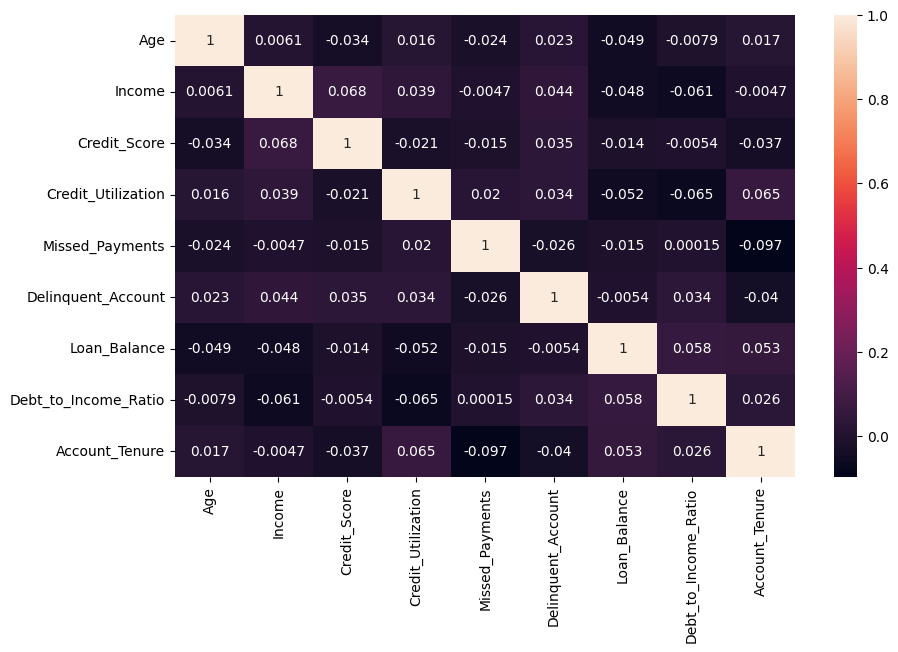

In [8]:
#visulaized
import seaborn as sn
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sn.heatmap(corr,annot=True)
plt.show()

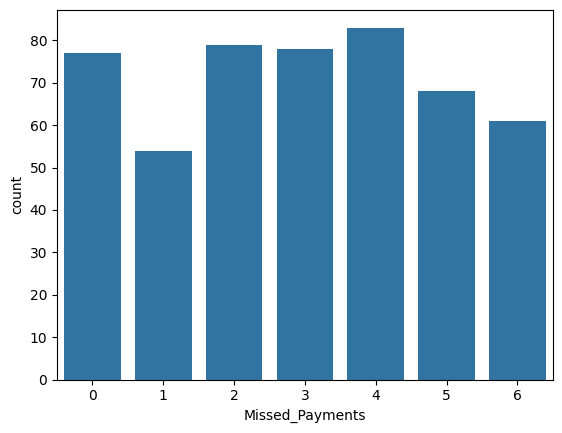

In [9]:
#Payment Behaviour Analysis
data['Missed_Payments'].value_counts()
sn.countplot(x='Missed_Payments',data=data)
plt.show()

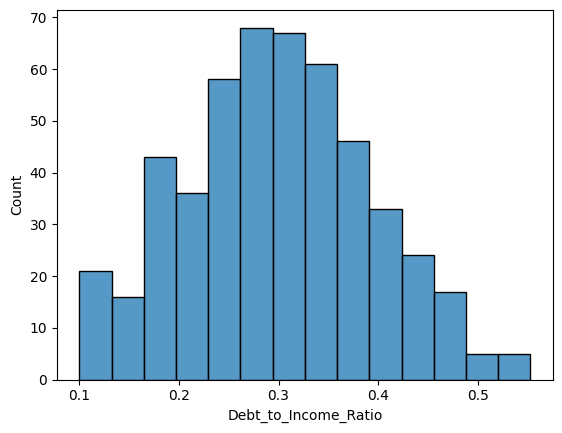

In [10]:
#Debt_To Income
data['Debt_to_Income_Ratio'].describe()
sn.histplot(data['Debt_to_Income_Ratio'])
plt.show()

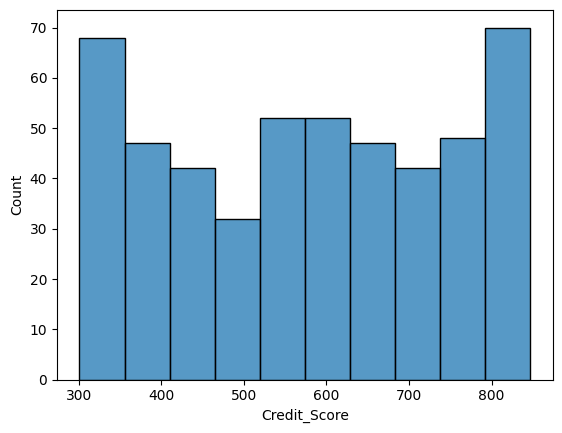

In [11]:
#Credit_score
sn.histplot(data['Credit_Score'])
plt.show()

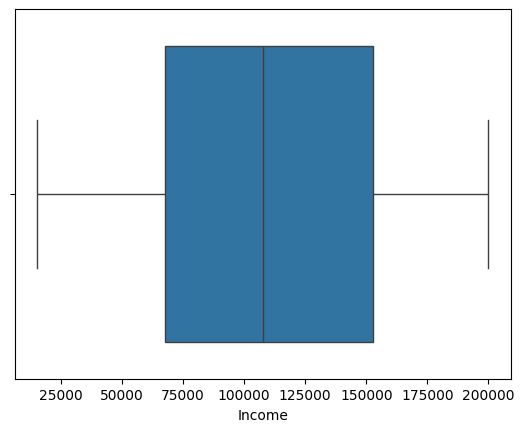

In [12]:
sn.boxplot(x=data['Income'])
plt.show()

In [13]:
#Predictive modeling
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,roc_auc_score
from sklearn.preprocessing import StandardScaler

In [14]:
X=data[['Credit_Score',
          'Debt_to_Income_Ratio',
          'Missed_Payments',
          'Loan_Balance',
          'Income']]
y=data['Delinquent_Account']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model=LogisticRegression(max_iter=1000,class_weight='balanced')
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [15]:
y_pred

array([1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1])

In [16]:
#Metrics
Accuracy = accuracy_score(y_test, y_pred)
Precision = precision_score(y_test, y_pred)
Recall = recall_score(y_test, y_pred)
F1 = f1_score(y_test, y_pred)
AUC = roc_auc_score(y_test, y_pred)

In [17]:
print("METRICS")
print("Accuracy",Accuracy)
print("Precision",Precision)
print("Recall",Recall)
print("F1",F1)
print("AUC",AUC)

METRICS
Accuracy 0.46
Precision 0.14285714285714285
Recall 0.5714285714285714
F1 0.22857142857142856
AUC 0.5066445182724253


In [18]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[38 48]
 [ 6  8]]


In [19]:
pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 20.4 MB/s  0:00:00a 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 795.4/795.4 kB 24.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 23.4 MB/s  0:00:006.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 21.0 MB/s  0:00:02 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [streamlit] 13/14 [streamlit]eck]
Note: you may need to restart the kernel to use updated packages.


In [22]:
import pickle
pickle.dump(model,open("model.pkl","wb"))